# LAB 1 

- Jerónimo Vásquez Ponce 202223824
- Jacobo Zarruk Estrada 202223913

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FunctionTransformer
from scipy.stats import shapiro
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Extracción de los datos

In [2]:
df = pd.read_csv("Datos Lab 1.csv")

## EDA

In [3]:
df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   object 
 1   Date of Service               1639 non-null   object 
 2   Sex                           1639 non-null   object 
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   object 
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   object 
 13  Dia

In [5]:
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


In [6]:
df.shape

(1639, 24)

### Reporte de calidad de los datos

In [7]:
def reporte_calidad(df):

    reporte_de_cualidad = {
        'Total datos': len(df),
        'Datos duplicados': df.duplicated().sum(),
        'Valores nulos': df.isnull().sum().to_dict(),
        'Tipos de datos': df.dtypes.astype(str).to_dict(),
        

    }

    return reporte_de_cualidad

print(reporte_calidad(df))

{'Total datos': 1639, 'Datos duplicados': 151, 'Valores nulos': {'Patient ID': 0, 'Date of Service': 0, 'Sex': 0, 'Age': 68, 'Weight (kg)': 73, 'Height (m)': 61, 'BMI': 53, 'Abdominal Circumference (cm)': 61, 'Blood Pressure (mmHg)': 0, 'Total Cholesterol (mg/dL)': 68, 'HDL (mg/dL)': 82, 'Fasting Blood Sugar (mg/dL)': 54, 'Smoking Status': 0, 'Diabetes Status': 0, 'Physical Activity Level': 0, 'Family History of CVD': 0, 'Height (cm)': 68, 'Waist-to-Height Ratio': 76, 'Systolic BP': 61, 'Diastolic BP': 85, 'Blood Pressure Category': 0, 'Estimated LDL (mg/dL)': 57, 'CVD Risk Score': 29, 'CVD Risk Level': 0}, 'Tipos de datos': {'Patient ID': 'object', 'Date of Service': 'object', 'Sex': 'object', 'Age': 'float64', 'Weight (kg)': 'float64', 'Height (m)': 'float64', 'BMI': 'float64', 'Abdominal Circumference (cm)': 'float64', 'Blood Pressure (mmHg)': 'object', 'Total Cholesterol (mg/dL)': 'float64', 'HDL (mg/dL)': 'float64', 'Fasting Blood Sugar (mg/dL)': 'float64', 'Smoking Status': 'obje

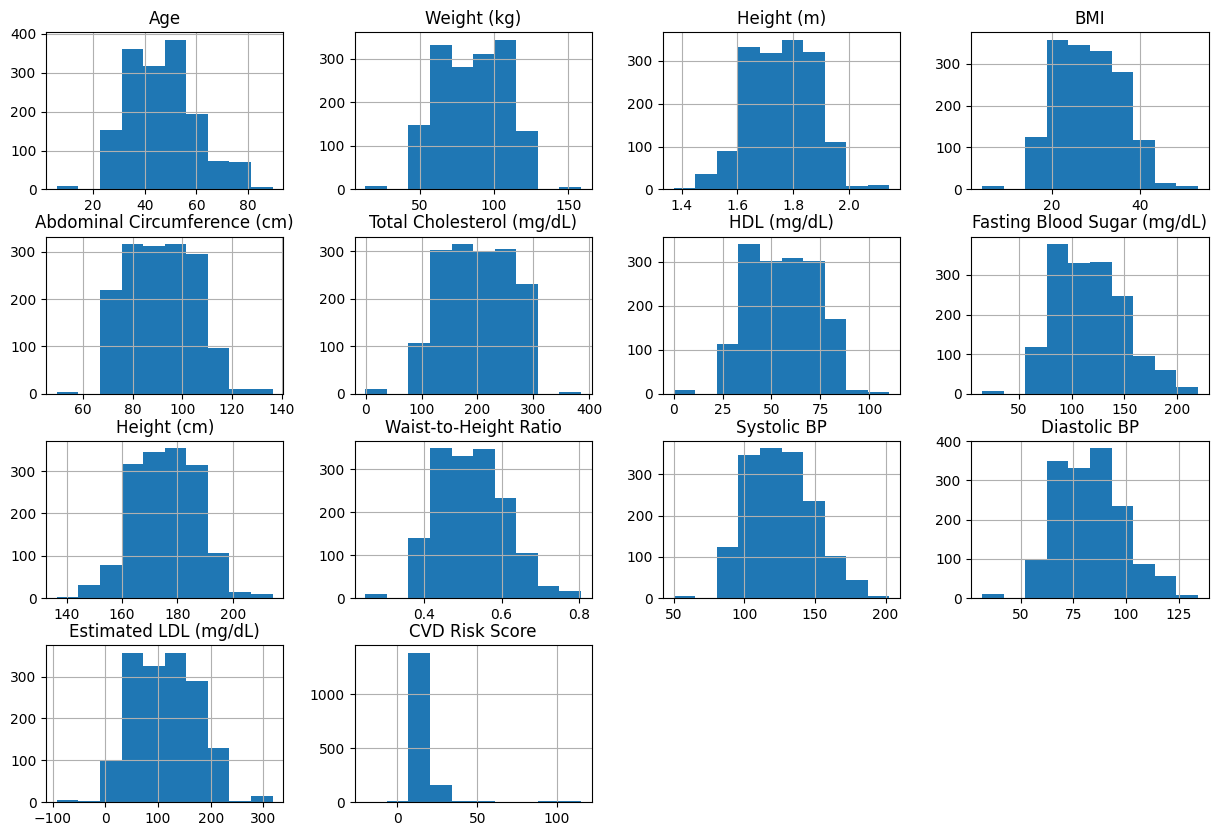

In [8]:
df.hist(figsize=(15,10))
plt.show()

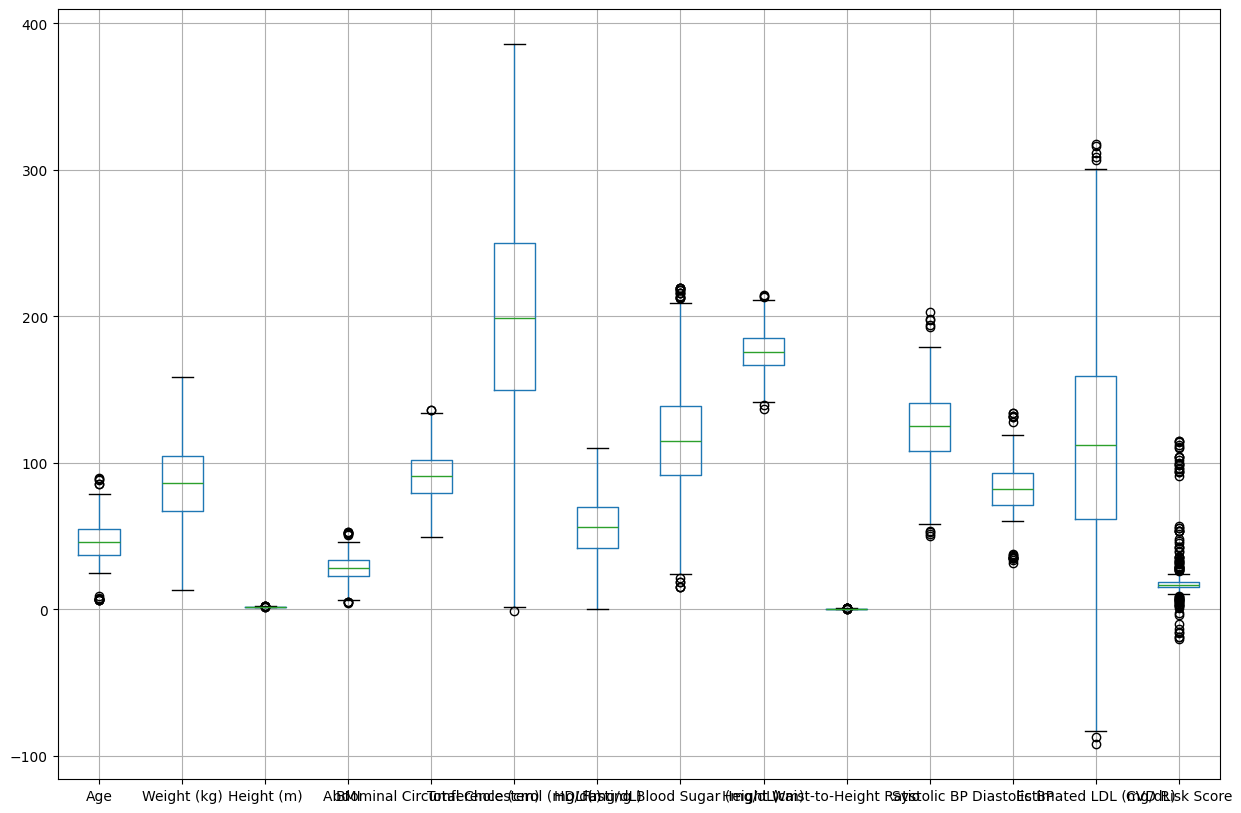

In [9]:
df.boxplot(figsize=(15,10))
plt.show()

In [10]:
def identificar_outliers(df, columna):

    
    
    Q1 = df[columna].quantile(0.25)  
    Q3 = df[columna].quantile(0.75) 
    IQR = Q3 - Q1  
    
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    
    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    indices_outliers = df[mask_outliers].index.tolist()
    outliers_df = df.loc[indices_outliers]
    
    
    limites = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }
    
    return indices_outliers, outliers_df, limites

In [11]:
def reporte_outliers(df):
    resultados = []
    
    for columna in df.select_dtypes(include='number').columns:
        indices, outliers, limites = identificar_outliers(df, columna)
        
        por_debajo = (df[columna] < limites['limite_inferior']).sum()
        por_encima = (df[columna] > limites['limite_superior']).sum()
        
        resultados.append({
            'columna': columna,
            'total Outliers': len(indices),
            'por debajo': por_debajo,
            'por encima': por_encima,
            'limite Inferior': round(limites['limite_inferior'], 2),
            'limite Superior': round(limites['limite_superior'], 2)
        })
    
    return pd.DataFrame(resultados)

reporte_outliers(df)

,columna,total Outliers,por debajo,por encima,limite Inferior,limite Superior
0,Age,15,10,5,10.00,82.00
1,Weight (kg),0,0,0,10.55,161.35
2,Height (m),8,3,5,1.39,2.13
3,BMI,11,4,7,5.56,51.01
4,Abdominal Circumference (cm),2,0,2,45.85,136.12
5,Total Cholesterol (mg/dL),1,1,0,0.00,400.00
6,HDL (mg/dL),0,0,0,0.00,112.00
7,Fasting Blood Sugar (mg/dL),21,6,15,21.50,209.50
8,Height (cm),5,2,3,140.00,212.00
9,Waist-to-Height Ratio,13,4,9,0.26,0.78


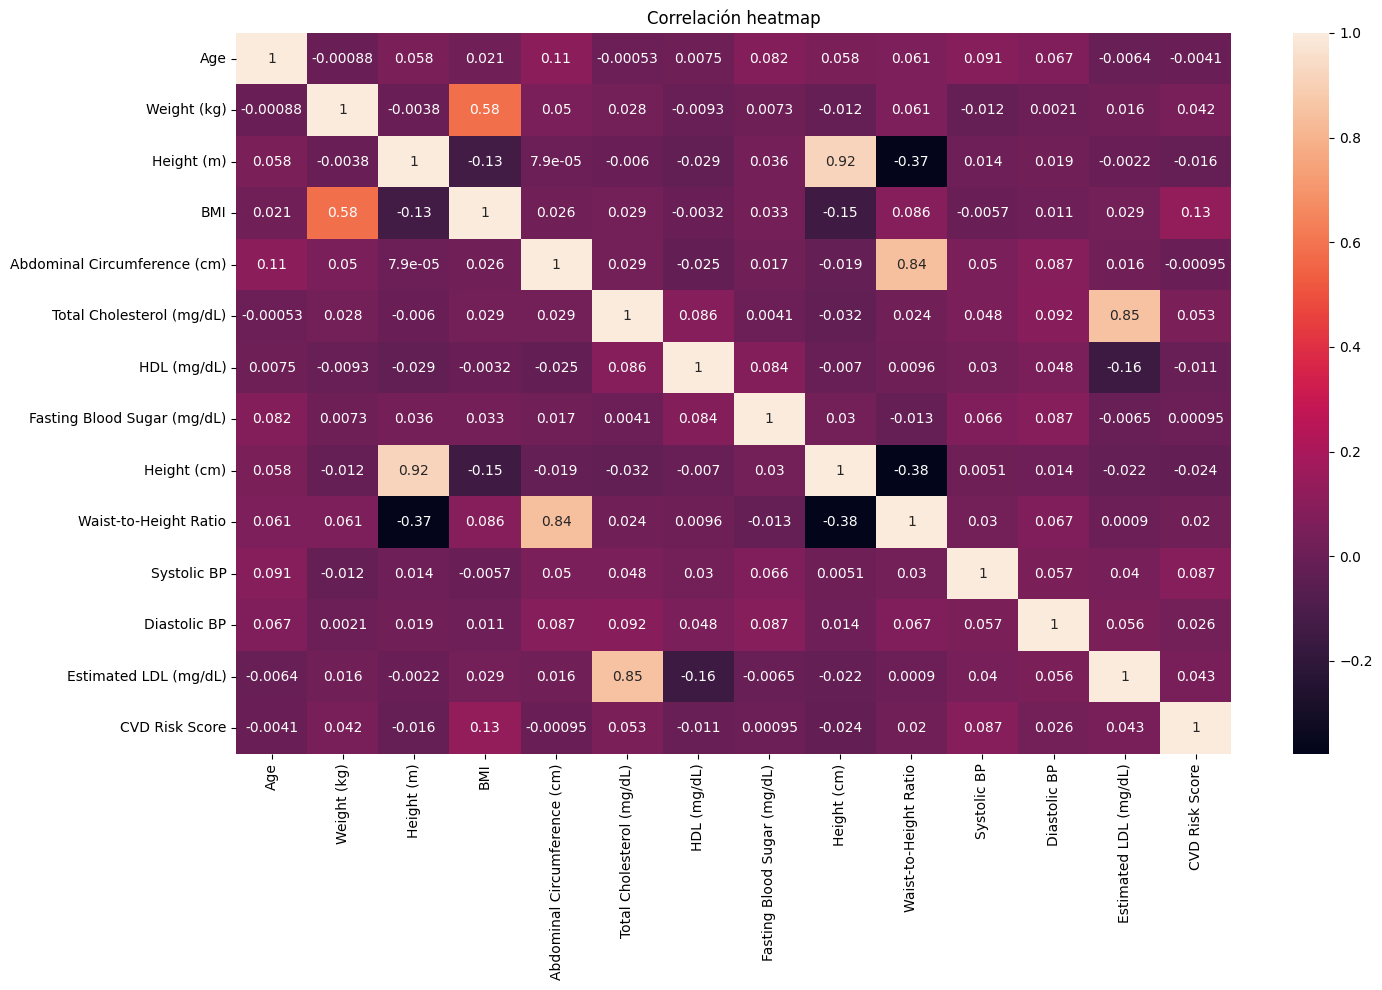

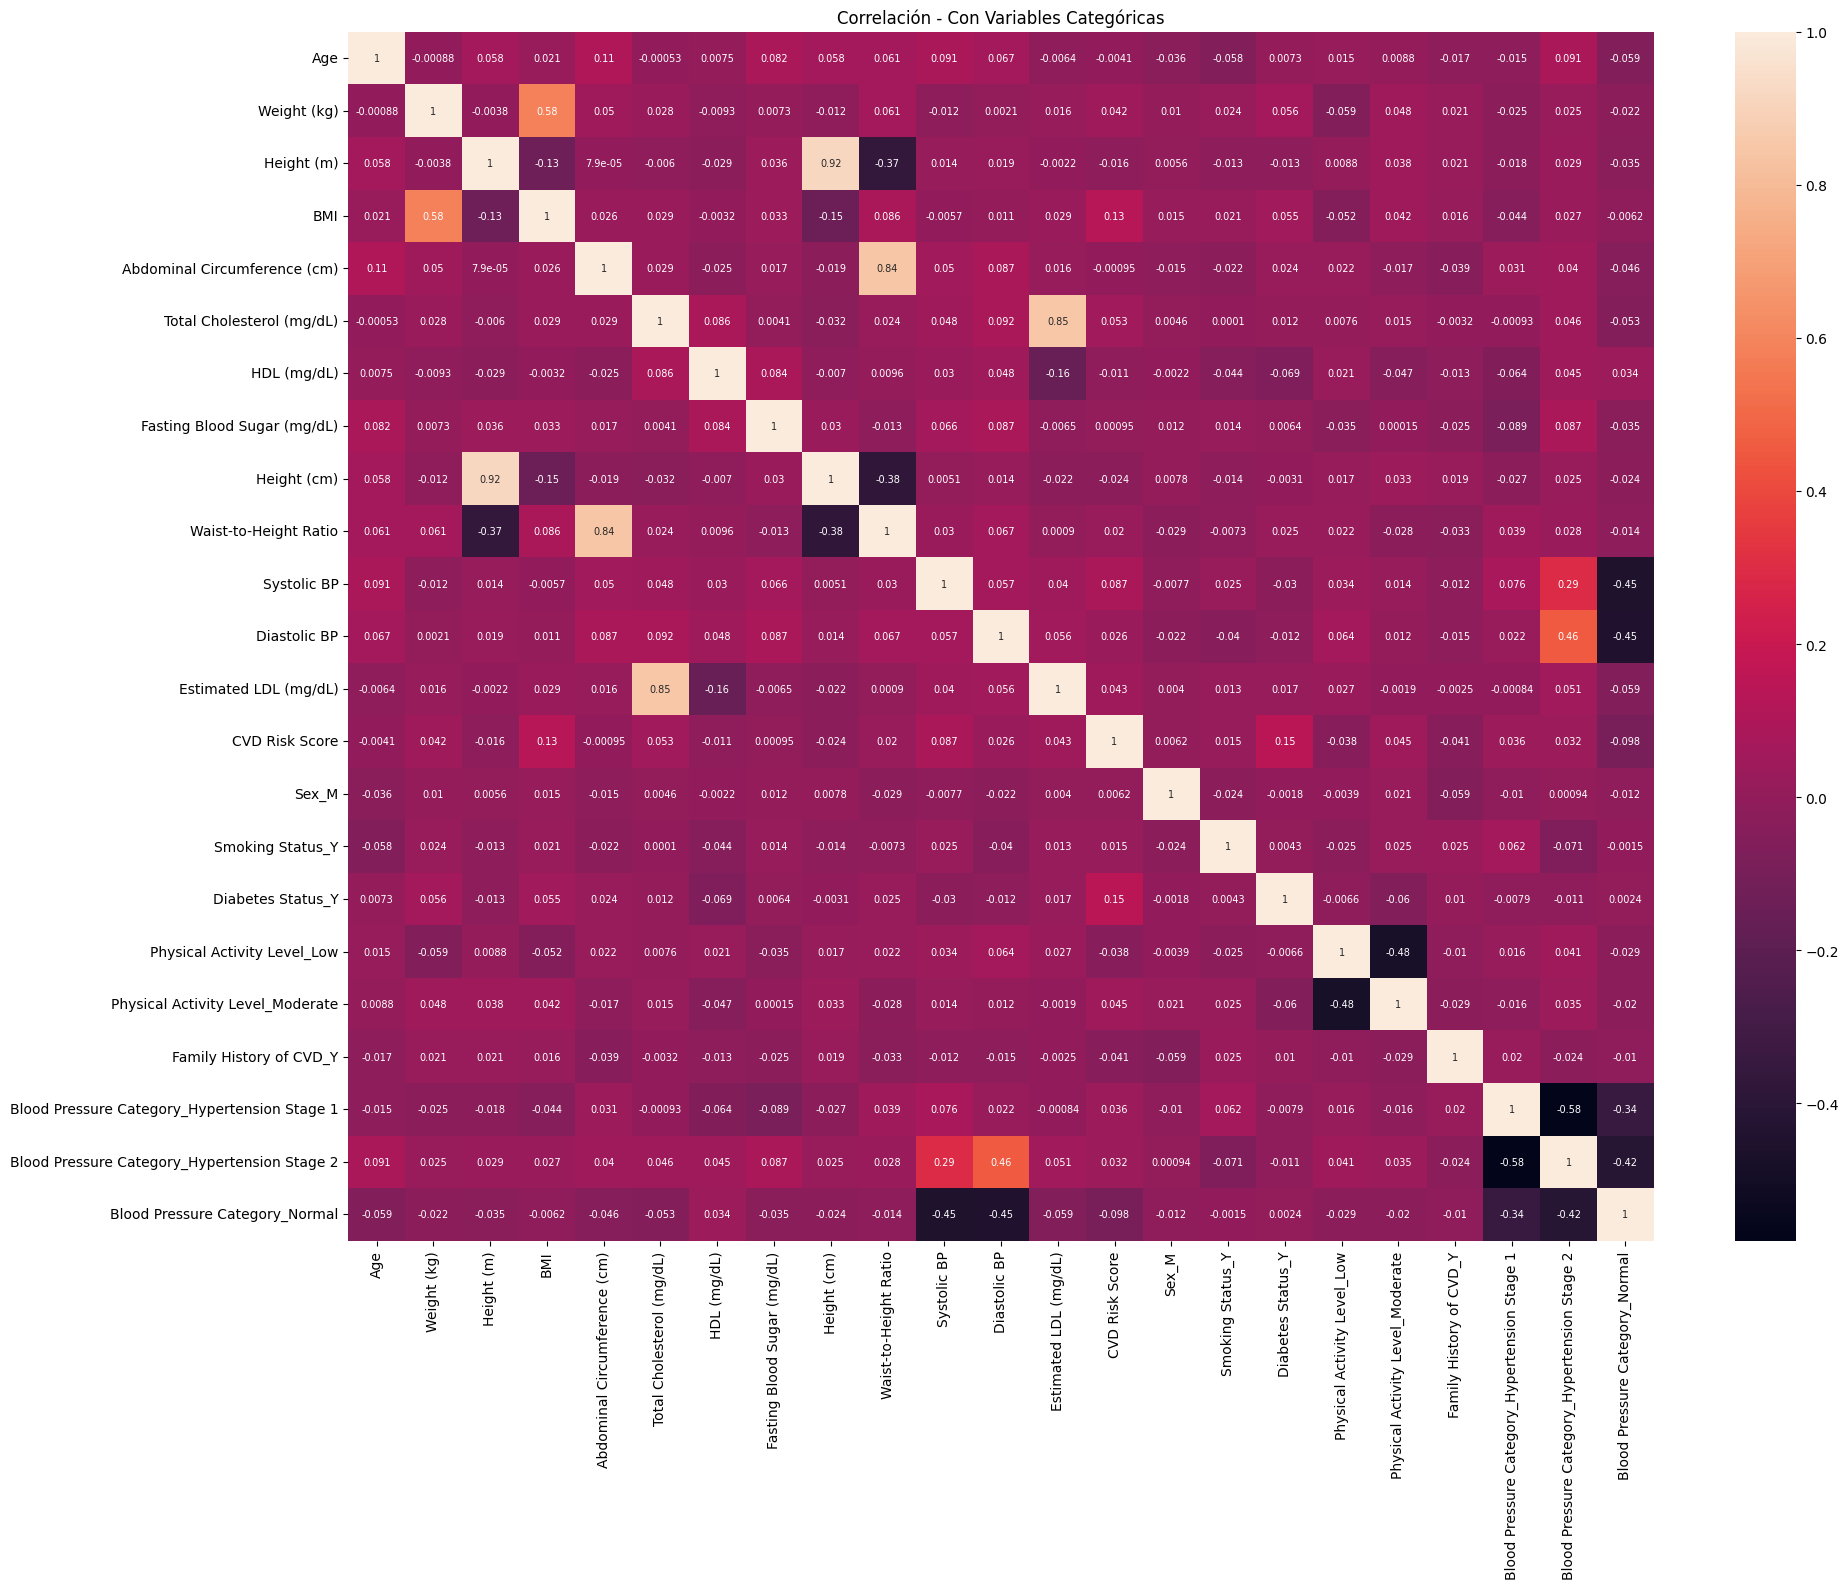

In [12]:
plt.figure(figsize=(15, 10))
corr_numeric = df.corr(numeric_only=True)
sns.heatmap(corr_numeric, annot=True)
plt.title('Correlación heatmap')
plt.tight_layout()
plt.show()


df_encoded = pd.get_dummies(df, columns=['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category'], drop_first=True)

plt.figure(figsize=(20, 16))
corr_encoded = df_encoded.corr(numeric_only=True)
sns.heatmap(corr_encoded, annot=True, annot_kws={'size': 7})
plt.title('Correlación - Con Variables Categóricas')
plt.tight_layout()
plt.show()

<Axes: xlabel='BMI', ylabel='CVD Risk Score'>

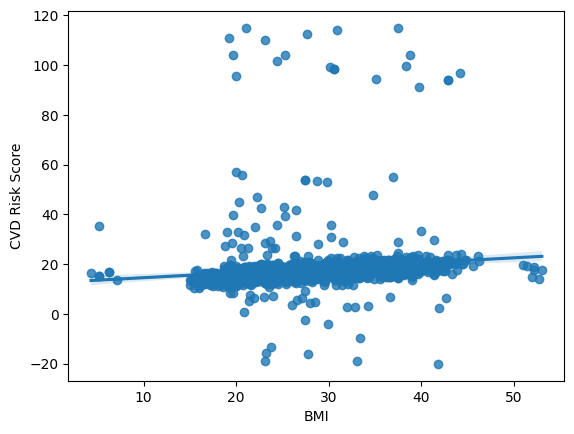

In [13]:
sns.regplot(data=df_encoded, x='BMI', y='CVD Risk Score')

## Análisis y Reporte de calidad de datos, outliers y correlaciones



### 1. Descripción general del conjunto de datos

El conjunto de datos analizado contiene 1639 registros y 23 columnas, las cuales incluyen variables numéricas y categóricas. Se identificaron 151 registros duplicados, lo que evidencia un problema de unicidad que debe ser tratado antes de realizar cualquier proceso de modelación.

En cuanto a los tipos de datos, el dataset está conformado por 10 variables de tipo object y 13 variables de tipo float64.

---

### 2. Calidad de los datos

El análisis de calidad se realizó evaluando: completitud, unicidad, consistencia y validez.

#### 2.1 Completitud

El análisis de completitud evidencia la presencia de valores nulos en múltiples variables relevantes del conjunto de datos:

- Age: 68 valores nulos  
- Weight (kg): 73 valores nulos  
- Height (m): 61 valores nulos  
- BMI: 53 valores nulos  
- Abdominal Circumference (cm): 61 valores nulos  
- Total Cholesterol (mg/dL): 68 valores nulos  
- HDL (mg/dL): 82 valores nulos  
- Fasting Blood Sugar (mg/dL): 54 valores nulos  
- Height (cm): 68 valores nulos  
- Waist-to-Height Ratio: 76 valores nulos  
- Systolic BP: 61 valores nulos  
- Diastolic BP: 85 valores nulos  
- Estimated LDL (mg/dL): 57 valores nulos  
- CVD Risk Score: 29 valores nulos  

Estos resultados indican problemas de completitud que requieren la aplicación de estrategias para mitigar este problema.

#### 2.2 Unicidad

Se identificaron 151 registros duplicados dentro del conjunto de datos. 
Estos resultados indican problemas de unicidad que requieren la aplicación de estrategias para mitigar este problema.

#### 2.3 Consistencia

El análisis de consistencia revela varios problemas estructurales en los datos:

- Existen dos variables que representan la altura de los individuos, una expresada en metros y otra en centímetros, lo cual introduce redundancia y posibles inconsistencias.
- La variable Date of service presenta múltiples formatos de fecha, tales como 20/03/2004, November 08, 2023 y 2021-05-27, lo que dificulta su procesamiento y análisis temporal.

Estos problemas requieren un proceso de estandarización previo a la modelación.

#### 2.4 Validez

Se identificaron valores que no son válidos desde el punto de vista clínico o lógico:

- En la variable Total Cholesterol (mg/dL) se presentan valores negativos, lo cual no es posible en la práctica.
- Las variables Estimated LDL (mg/dL) y CVD Risk Score también presentan valores negativos, lo que representa un problema de validez de los datos.

Estos registros deben ser revisados para mitigar futuros problemas en la modelación.

---

### 3. Análisis de outliers

El análisis de valores atípicos se realizó utilizando límites inferiores y superiores definidos a partir de criterios estadísticos. Los resultados indican que varias variables presentan una cantidad considerable de outliers, tanto por debajo como por encima de los límites esperados.

#### 3.1 Distribución de outliers por variable

- CVD Risk Score presenta 87 outliers, con 29 valores por debajo del límite inferior y 58 por encima del límite superior.
- Fasting Blood Sugar (mg/dL) presenta 21 outliers, distribuidos entre valores bajos y altos.
- Diastolic BP presenta 18 outliers, principalmente por debajo del límite inferior.
- Age presenta 15 outliers, los cuales pueden corresponder a valores extremos reales, pero que influyen en la estabilidad del modelo.
- Waist-to-Height Ratio presenta 13 outliers, algunos potencialmente inconsistentes desde el punto de vista clínico.
- BMI presenta 11 outliers, incluyendo valores poco plausibles fisiológicamente.
- Systolic BP presenta 9 outliers.
- Estimated LDL (mg/dL) presenta 7 outliers, reforzando los problemas de validez previamente identificados.
- Height (m) y Height (cm) presentan outliers, lo que refuerza los problemas de consistencia entre unidades.
- Weight (kg) y HDL (mg/dL) no presentan outliers relevantes según los criterios aplicados.

#### 3.2 Interpretación de los outliers

La presencia de múltiples outliers en variables clínicas clave como CVD Risk Score, Fasting Blood Sugar, BMI y colesterol puede afectar significativamente el desempeño de modelo. Por ende, se debe lidiar y mitigar con estos outliers

---

### 4. Análisis de correlaciones y selección de variables

Se realizó un proceso de codificación de las variables categóricas con el fin de evaluar su correlación con la variable objetivo CVD Risk Score. Se seleccionaron aquellas variables cuyo coeficiente de correlación es superior a 0.15, considerándolas relevantes.

Las variables seleccionadas son:

- BMI  
- Total Cholesterol (mg/dL)  
- Diabetes Status_Y  
- Systolic BP  
- Estimated LDL (mg/dL)  
- Weight (kg)  
- Blood Pressure Category_Hypertension Stage 2  



#### 4.1. Interpretación de las correlaciones

El análisis del mapa de calor, tanto para variables numéricas como para variables codificadas, muestra que las variables con mayor correlación con CVD Risk Score son:

- BMI con un coeficiente de correlación de 0.421  
- Total Cholesterol (mg/dL) con 0.364  
- Diabetes Status_Y con 0.355  
- Systolic BP con 0.325  
- Estimated LDL (mg/dL) con 0.324  
- Weight (kg) con 0.28  
- Blood Pressure Category_Hypertension Stage 2 con 0.161  

Las gráficas de regresión confirman estas relaciones, por lo que únicamente se consideran variables con coeficientes de correlación superiores a 0.15 lo que demuestra significancia correlativa con nuetra variable objetivo CVD Risk Score.

---

### 5. Conclusiones análisis

- El análisis exploratorio de datos permitió identificar problemas de calidad asociados a la completitud, unicidad, consistencia y validez del conjunto de datos.
- Se evidenció la presencia de valores nulos en múltiples variables relevantes, así como registros duplicados que pueden afectar la representatividad de la información.
- Se identificaron inconsistencias estructurales y valores no válidos, como variables redundantes y valores negativos en variables clínicas.
- El análisis de outliers mostró una cantidad considerable de valores atípicos en variables clave, lo cual puede impactar negativamente el desempeño de los modelos predictivos.
- El estudio de correlaciones permitió seleccionar un subconjunto de variables con mayor relación con la variable objetivo CVD Risk Score.
- Todos estos problemas deben ser mitigados mediante procesos adecuados de limpieza y preprocesamiento para asegurar la construcción del mejor modelo posible.



## Transformación - Preparación de los datos

Nuestra propuesta de transformación de los datos es la siguiente:

1) Datos faltantes o nulos: Se utilizará la mediana de cada columna para imputar los valores nulos. Se elige la mediana sobre el promedio porque es más robusta ante distribuciones con desviaciones estándar altas o presencia de outliers, y sobre la moda porque la mediana representa mejor el valor central de variables numéricas continuas. Para las variables categóricas, se imputará con la moda (valor más frecuente).

2) Datos duplicados: Se eliminarán los 151 registros duplicados identificados, conservando únicamente una instancia de cada registro. Esto se realiza antes de cualquier división de datos para asegurar que no existan registros repetidos entre los conjuntos de entrenamiento y prueba.

3) Problemas de consistencia: Se eliminará la columna 'Height (cm)' por ser redundante con 'Height (m)'. Adicionalmente, se eliminarán las columnas 'Patient ID' y 'Date of Service' por no aportar valor predictivo al modelo, y la columna 'CVD Risk Level' por ser otra representación de la variable objetivo, lo cual introduciría data leakage.

4) Variable objetivo nula: Se eliminarán las 29 filas donde 'CVD Risk Score' es nulo, ya que no tiene sentido imputar la variable que se busca predecir.

5) Outliers: Se reemplazarán los outliers por los límites definidos mediante el método IQR. Los valores por debajo del límite inferior se sustituirán por dicho límite, y los valores por encima del límite superior se sustituirán por el límite superior. Esta decisión se toma para reducir el impacto de valores extremos en el modelo sin perder registros.

6) Codificación de variables categóricas: Para el segundo modelo, se aplicará One-Hot Encoding con eliminación de la primera categoría (drop='first') para evitar multicolinealidad. Esto permite que el modelo capture la influencia de variables como Diabetes Status, Smoking Status, Sex, Physical Activity Level, Family History of CVD y Blood Pressure Category.

7) Escalado de variables numéricas: Para el segundo modelo, se aplicará MinMaxScaler sobre las variables numéricas, lo cual normaliza los valores al rango [0, 1]. Esto permite que todas las variables contribuyan de forma equitativa al modelo sin que aquellas con rangos más amplios dominen la predicción.


## Preparación de los datos

In [14]:
df = df.drop_duplicates()
df = df.drop(columns=['Height (cm)', 'Patient ID', 'Date of Service', 'CVD Risk Level', 'Blood Pressure (mmHg)'])
df = df.dropna(subset=['CVD Risk Score'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1638
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1460 non-null   object 
 1   Age                           1400 non-null   float64
 2   Weight (kg)                   1394 non-null   float64
 3   Height (m)                    1407 non-null   float64
 4   BMI                           1414 non-null   float64
 5   Abdominal Circumference (cm)  1410 non-null   float64
 6   Total Cholesterol (mg/dL)     1398 non-null   float64
 7   HDL (mg/dL)                   1387 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1412 non-null   float64
 9   Smoking Status                1460 non-null   object 
 10  Diabetes Status               1460 non-null   object 
 11  Physical Activity Level       1460 non-null   object 
 12  Family History of CVD         1460 non-null   object 
 13  Waist-to

In [15]:
for columna in df.select_dtypes(include='number').columns:
    indices, outliers, limites = identificar_outliers(df, columna)
    df.loc[df[columna] < limites['limite_inferior'], columna] = limites['limite_inferior']
    df.loc[df[columna] > limites['limite_superior'], columna] = limites['limite_superior']


X = df.drop(columns=['CVD Risk Score'])
y = df['CVD Risk Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [16]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1095, 18) (1095,)
(365, 18) (365,)


In [17]:
# Modelo 1 solo numericas
num_cols_modelo1 = ['BMI', 'Total Cholesterol (mg/dL)', 'Systolic BP', 'Estimated LDL (mg/dL)', 'Weight (kg)']

#Modelo 2 Numericas + Categoricas
num_cols_modelo2 = ['BMI', 'Total Cholesterol (mg/dL)', 'Systolic BP', 'Estimated LDL (mg/dL)', 'Weight (kg)']
cat_cols_modelo2 = ['Diabetes Status', 'Blood Pressure Category']

## Pipeline

In [18]:
def capping_outliers(X):
    X_copy = X.copy()
    for columna in X_copy.select_dtypes(include='number').columns:
        indices, outliers, limites = identificar_outliers(X_copy, columna)
        X_copy.loc[X_copy[columna] < limites['limite_inferior'], columna] = limites['limite_inferior']
        X_copy.loc[X_copy[columna] > limites['limite_superior'], columna] = limites['limite_superior']
    return X_copy

capping_outliers_tr = FunctionTransformer(capping_outliers)

In [19]:
numeric_transformer_m1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [20]:
preprocessor_m1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_m1, num_cols_modelo1)
    ],
    remainder='drop'
)

In [21]:
pipeline_modelo1 = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor_m1),
])

pipeline_modelo1

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...00238A6985AB0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [22]:
Xt_train_m1 = pipeline_modelo1.fit_transform(X_train)

feature_names_m1 = pipeline_modelo1.named_steps['preprocesamiento'].get_feature_names_out()
Xt_train_m1_df = pd.DataFrame(Xt_train_m1, columns=feature_names_m1, index=X_train.index)

Xt_train_m1_df.head()

,num__BMI,num__Total Cholesterol (mg/dL),num__Systolic BP,num__Estimated LDL (mg/dL),num__Weight (kg)
1127,24.100,194.0,135.0,91.0,78.800
875,39.000,135.0,96.0,48.0,107.600
1542,29.587,215.0,144.0,103.0,66.855
669,25.887,255.0,157.0,180.0,108.125
878,15.700,243.0,113.0,175.0,52.500


In [23]:
numeric_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])


categorical_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [24]:
preprocessor_m2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_m2, num_cols_modelo2),
        ('cat', categorical_transformer_m2, cat_cols_modelo2)
    ],
    remainder='drop'
)

In [25]:
pipeline_modelo2 = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor_m2),
])

pipeline_modelo2

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...00238A6985AB0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [26]:
Xt_train_m2 = pipeline_modelo2.fit_transform(X_train)


feature_names_m2 = pipeline_modelo2.named_steps['preprocesamiento'].get_feature_names_out()
Xt_train_m2_df = pd.DataFrame(Xt_train_m2.toarray() if hasattr(Xt_train_m2, 'toarray') else Xt_train_m2,columns=feature_names_m2, index=X_train.index)

Xt_train_m2_df.head()

,num__BMI,num__Total Cholesterol (mg/dL),num__Systolic BP,num__Estimated LDL (mg/dL),num__Weight (kg),cat__Diabetes Status_Y,cat__Blood Pressure Category_Hypertension Stage 1,cat__Blood Pressure Category_Hypertension Stage 2,cat__Blood Pressure Category_Normal
1127,0.407738,0.502988,0.579545,0.449032,0.451178,0.0,1.0,0.0,0.0
875,0.732938,0.341704,0.284091,0.338065,0.649440,0.0,0.0,0.0,1.0
1542,0.527495,0.560394,0.647727,0.480000,0.368947,0.0,0.0,1.0,0.0
669,0.446740,0.669739,0.746212,0.678710,0.653054,1.0,0.0,1.0,0.0
878,0.224404,0.636936,0.412879,0.665806,0.270126,0.0,0.0,1.0,0.0


In [27]:
#test Modelo 1
Xt_test_m1 = pipeline_modelo1.transform(X_test)
feature_names_m1 = pipeline_modelo1.named_steps['preprocesamiento'].get_feature_names_out()
Xt_test_m1_df = pd.DataFrame(Xt_test_m1, columns=feature_names_m1, index=X_test.index)

#test Modelo 2
Xt_test_m2 = pipeline_modelo2.transform(X_test)
feature_names_m2 = pipeline_modelo2.named_steps['preprocesamiento'].get_feature_names_out()
Xt_test_m2_df = pd.DataFrame(Xt_test_m2.toarray() if hasattr(Xt_test_m2, 'toarray') else Xt_test_m2,columns=feature_names_m2, index=X_test.index)

In [28]:
rta_df = pd.concat([Xt_train_m2_df, Xt_test_m2_df])

array([[<Axes: title={'center': 'num__BMI'}>,
        <Axes: title={'center': 'num__Total Cholesterol (mg/dL)'}>,
        <Axes: title={'center': 'num__Systolic BP'}>],
       [<Axes: title={'center': 'num__Estimated LDL (mg/dL)'}>,
        <Axes: title={'center': 'num__Weight (kg)'}>,
        <Axes: title={'center': 'cat__Diabetes Status_Y'}>],
       [<Axes: title={'center': 'cat__Blood Pressure Category_Hypertension Stage 1'}>,
        <Axes: title={'center': 'cat__Blood Pressure Category_Hypertension Stage 2'}>,
        <Axes: title={'center': 'cat__Blood Pressure Category_Normal'}>]],
      dtype=object)

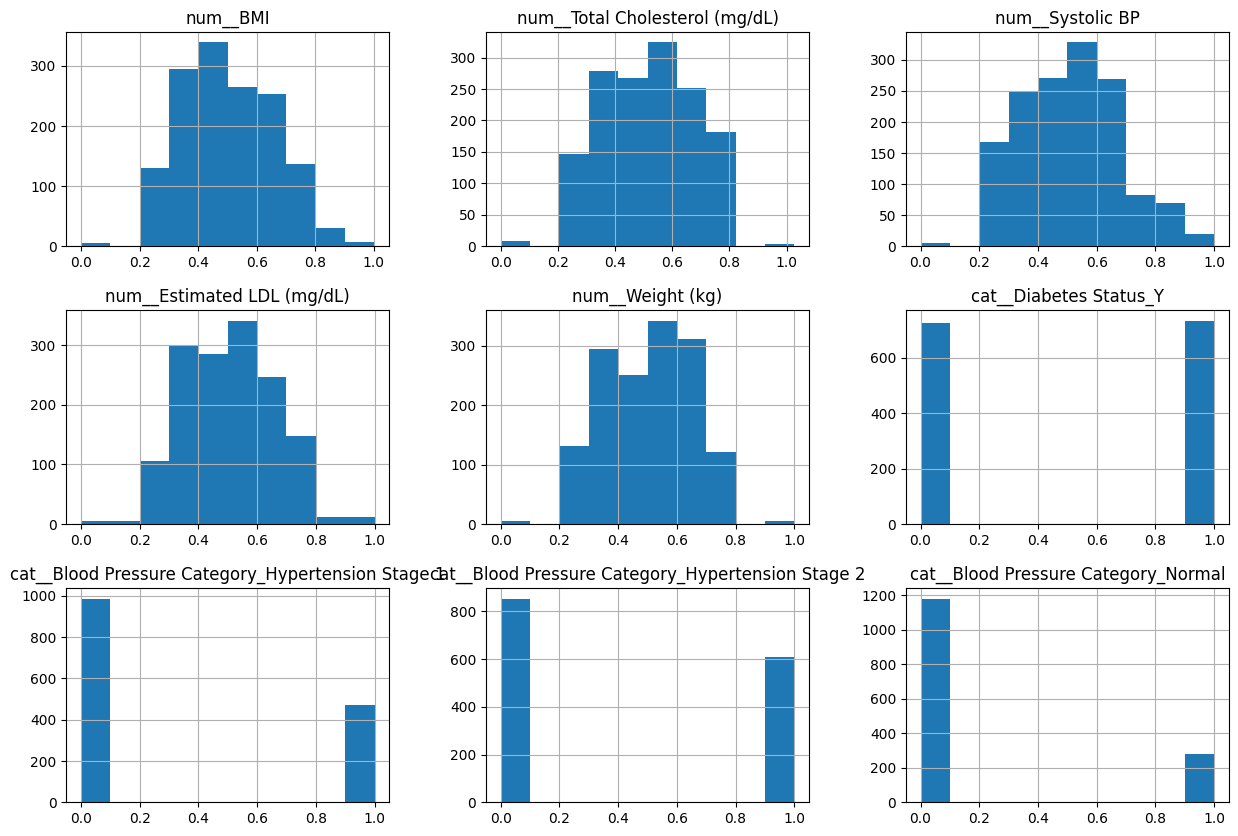

In [29]:
rta_df.hist(figsize=(15,10))

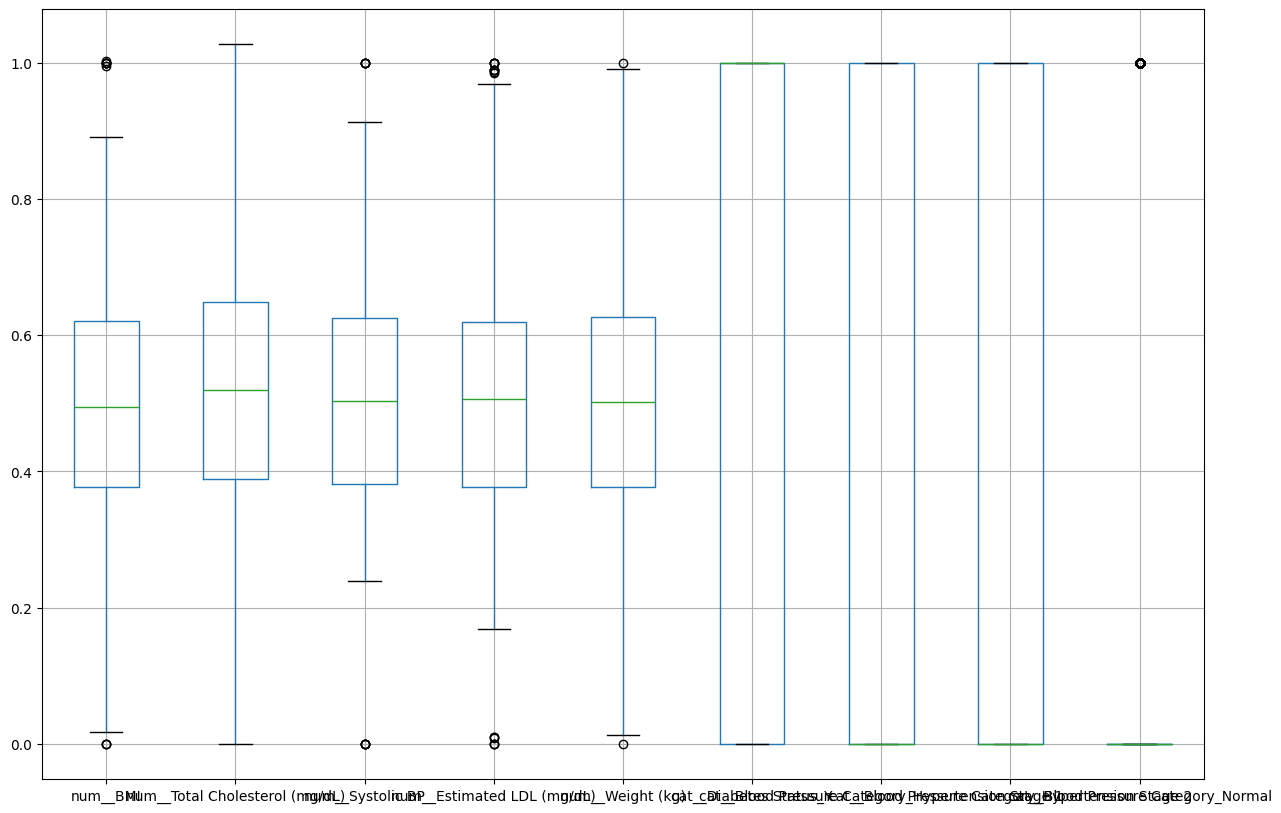

In [30]:
rta_df.boxplot(figsize=(15,10))
plt.show()

## Estrategia de modelación

Se construirán dos modelos de regresión lineal con estrategias de preparación de datos diferentes, con el fin de comparar su rendimiento y seleccionar el mejor.

### Modelo 1 — Regresión lineal directa (sin encoding ni escalado)

Este modelo utiliza únicamente las 5 variables numéricas con mayor correlación con CVD Risk Score, identificadas en el análisis exploratorio:
- BMI (0.421)
- Total Cholesterol (mg/dL) (0.364)
- Systolic BP (0.325)
- Estimated LDL (mg/dL) (0.324)
- Weight (kg) (0.28)

La preparación consiste únicamente en la imputación de nulos con la mediana. No se aplica escalado ni codificación de variables categóricas. Este enfoque busca un modelo simple e interpretable que aproveche las relaciones lineales más fuertes encontradas en el EDA.

### Modelo 2 — Regresión lineal con encoding y escalado

Este modelo incorpora tanto las 5 variables numéricas del Modelo 1 como las variables categóricas relevantes identificadas en el análisis de correlación:
- Diabetes Status (correlación de 0.355 con la categoría Y)
- Blood Pressure Category (correlación de 0.161 con Hypertension Stage 2)

La preparación incluye:
- Imputación de nulos (mediana para numéricas, moda para categóricas)
- MinMaxScaler para las variables numéricas
- One-Hot Encoding (drop='first') para las variables categóricas

Este enfoque busca capturar información adicional proveniente de las variables categóricas y estandarizar las escalas para que todas las variables contribuyan de forma equitativa al modelo.


## Modelo 1

In [31]:
Modelo1 = LinearRegression()

Modelo1.fit(Xt_train_m1_df,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
multi_coef = Modelo1.coef_
multi_intercept = Modelo1.intercept_

print('Coefficients: ', multi_coef)
print('Intercept: ', multi_intercept)

Coefficients:  [0.15819797 0.01522274 0.04203275 0.00356553 0.00757959]
Intercept:  3.283710649209741


Dando como resultado la siguiente ecuación de la regresión para predecir CVD Risk Score:

y = 3.2837 + (0.1582 * BMI) + (0.0152 * Total Cholesterol (mg/dL)) + (0.0420 * Systolic BP) + (0.0036 * Estimated LDL (mg/dL)) + (0.0076 * Weight (kg))

## Modelo 2

In [33]:
Modelo2 = LinearRegression()

Modelo2.fit(Xt_train_m2_df,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
multi_coef = Modelo2.coef_
multi_intercept = Modelo2.intercept_

print('Coefficients: ', multi_coef)
print('Intercept: ', multi_intercept)

Coefficients:  [ 7.02279742  5.56266921  5.36660728  1.12915277  0.94258783  2.00005009
 -0.21537076  0.04077146 -0.61219004]
Intercept:  6.132706633456275


Dando como resultado la siguiente ecuación de la regresión para predecir CVD Risk Score:

y = 6.1327 + (7.0228 * BMI) + (5.5627 * Total Cholesterol (mg/dL)) + (5.3666 * Systolic BP) + (1.1292 * Estimated LDL (mg/dL)) + (0.9426 * Weight (kg)) + (2.0001 * Diabetes Status Y) + (-0.2154 * BP Hypertension Stage 1) + (0.0408 * BP Hypertension Stage 2) + (-0.6122 * BP Normal)

## Evaluacion modelos

### Modelo 1

In [35]:
y_train_pred_m1 = Modelo1.predict(Xt_train_m1_df)
y_test_pred_m1 = Modelo1.predict(Xt_test_m1_df)

In [52]:
print("Train")
print(f"Score: {Modelo1.score(Xt_train_m1_df, y_train)} ")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_m1)} ")
print(f"MSE: {mean_squared_error(y_train, y_train_pred_m1)} ")
print(f"R^2: {r2_score(y_train, y_train_pred_m1)} ")
print(f'RMSE: {root_mean_squared_error(y_train, y_train_pred_m1)}')

print("\nTest")
print(f"Score: {Modelo1.score(Xt_test_m1_df, y_test)} ")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_m1)} ")
print(f"MSE: {mean_squared_error(y_test, y_test_pred_m1)} ")
print(f"R^2: {r2_score(y_test, y_test_pred_m1)} ")
print(f'RMSE: {root_mean_squared_error(y_test, y_test_pred_m1)}')

Train
Score: 0.3863514172666893 
MAE: 1.5450804799360724 
MSE: 5.708090015770525 
R^2: 0.3863514172666893 
RMSE: 2.3891609438818735

Test
Score: 0.4297882057262111 
MAE: 1.5690445115042808 
MSE: 5.5054364616037255 
R^2: 0.4297882057262111 
RMSE: 2.346366651144643


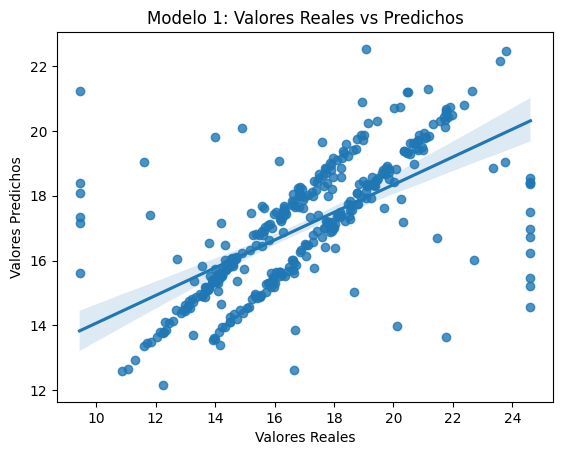

In [37]:
sns.regplot(x=y_test, y=y_test_pred_m1)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Modelo 1: Valores Reales vs Predichos')
plt.show()

In [55]:
residuales = np.array(y_train - y_train_pred_m1)

In [56]:
X_vif = Xt_train_m1_df.select_dtypes(include="number").copy()
clean_columns = (
    X_vif.columns
         .str.replace("^num__", "", regex=True)
         .str.replace("^cat__", "", regex=True)
)
vif_values = []
with np.errstate(divide="ignore", invalid="ignore"):
    for i in range(X_vif.shape[1]):
        vif = variance_inflation_factor(X_vif.values, i)
        vif_values.append(vif)

vif_data = pd.DataFrame({
    "Variable": clean_columns,
    "VIF": vif_values
})
print(vif_data)

                    Variable        VIF
0                        BMI  22.120762
1  Total Cholesterol (mg/dL)  30.183896
2                Systolic BP  18.208680
3      Estimated LDL (mg/dL)  11.734167
4                Weight (kg)  23.069763


Shapiro-Wilk p-value: 1.2450836763232828e-34


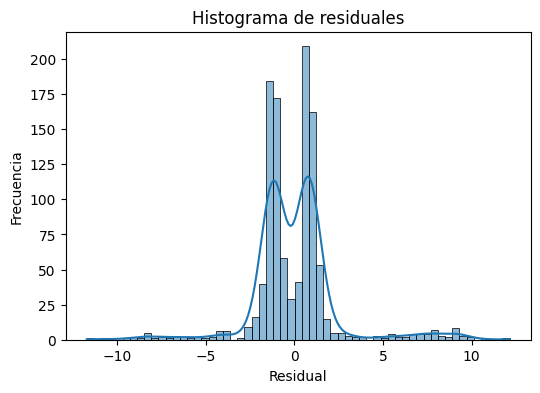

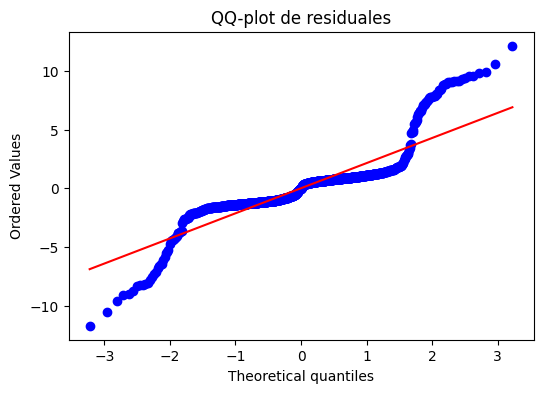

In [57]:
estat, p_shapiro = shapiro(residuales)
print("Shapiro-Wilk p-value:", p_shapiro)

plt.figure(figsize=(6, 4))
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuales")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(6, 4))
stats.probplot(residuales, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")
plt.show()

In [58]:
X_num = Xt_train_m1_df.select_dtypes(include="number").copy()
mask = np.isfinite(X_num).all(axis=1)
X_num_clean = X_num[mask]
resid_clean = residuales[mask]
X_num_const = sm.add_constant(X_num_clean)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid_clean, X_num_const)

print("Estadístico Breusch-Pagan:", bp_stat)
print("p-value Breusch-Pagan   :", bp_pvalue)

Estadístico Breusch-Pagan: 6.095268679442754
p-value Breusch-Pagan   : 0.2970589532354212


In [59]:
dw = durbin_watson(residuales)
print("Durbin-Watson:", dw)

Durbin-Watson: 1.9346591220131208


### Modelo 2

In [38]:
y_train_pred_m2 = Modelo2.predict(Xt_train_m2_df)
y_test_pred_m2 = Modelo2.predict(Xt_test_m2_df)

In [53]:
print("Train")
print(f"Score: {Modelo2.score(Xt_train_m2_df, y_train)} ")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_m2)} ")
print(f"MSE: {mean_squared_error(y_train, y_train_pred_m2)} ")
print(f"R^2: {r2_score(y_train, y_train_pred_m2)} ")
print(f'RMSE: {root_mean_squared_error(y_train, y_train_pred_m2)}')

print("\nTest")
print(f"Score: {Modelo2.score(Xt_test_m2_df, y_test)} ")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_m2)} ")
print(f"MSE: {mean_squared_error(y_test, y_test_pred_m2)} ")
print(f"R^2: {r2_score(y_test, y_test_pred_m2)} ")
print(f'RMSE: {root_mean_squared_error(y_test, y_test_pred_m2)}')

Train
Score: 0.49993132162097054 
MAE: 0.9878021208758798 
MSE: 4.651582535301687 
R^2: 0.49993132162097054 
RMSE: 2.1567527756564235

Test
Score: 0.5441600176738861 
MAE: 0.976357413634389 
MSE: 4.401168275642496 
R^2: 0.5441600176738861 
RMSE: 2.097896154637425


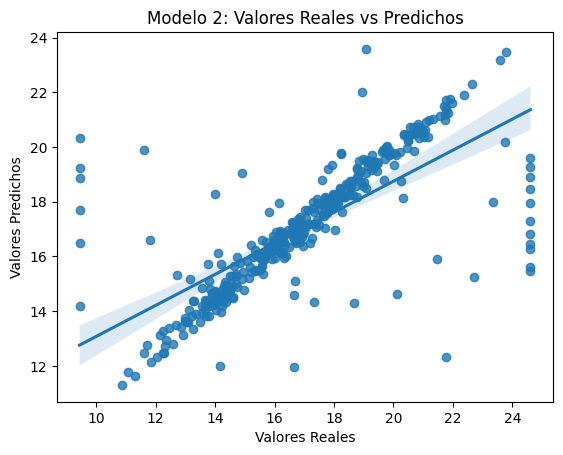

In [40]:
sns.regplot(x=y_test, y=y_test_pred_m2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Modelo 2: Valores Reales vs Predichos')
plt.show()

In [60]:
residuales_2 = np.array(y_train - y_train_pred_m2)

In [64]:
X_vif_2 = Xt_train_m2_df.select_dtypes(include="number").copy()
clean_columns = (
    X_vif_2.columns
         .str.replace("^num__", "", regex=True)
         .str.replace("^cat__", "", regex=True)
)
vif_values = []
with np.errstate(divide="ignore", invalid="ignore"):
    for i in range(X_vif_2.shape[1]):
        vif = variance_inflation_factor(X_vif_2.values, i)
        vif_values.append(vif)

vif_data = pd.DataFrame({
    "Variable": clean_columns,
    "VIF": vif_values
})
print(vif_data)

                                       Variable        VIF
0                                           BMI  15.313784
1                     Total Cholesterol (mg/dL)  31.239968
2                                   Systolic BP  10.485274
3                         Estimated LDL (mg/dL)  30.230037
4                                   Weight (kg)  16.760194
5                             Diabetes Status_Y   1.982944
6  Blood Pressure Category_Hypertension Stage 1   4.421200
7  Blood Pressure Category_Hypertension Stage 2   5.870836
8                Blood Pressure Category_Normal   2.631204


Shapiro-Wilk p-value: 8.306643738575014e-44


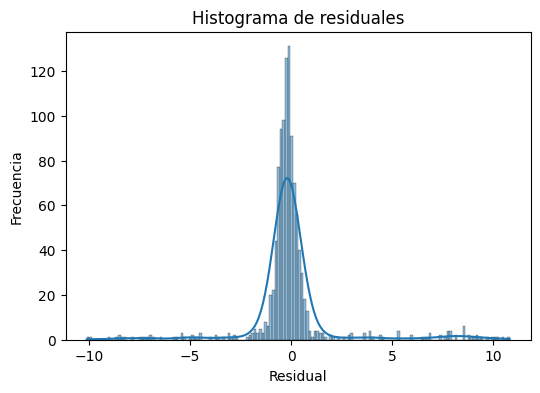

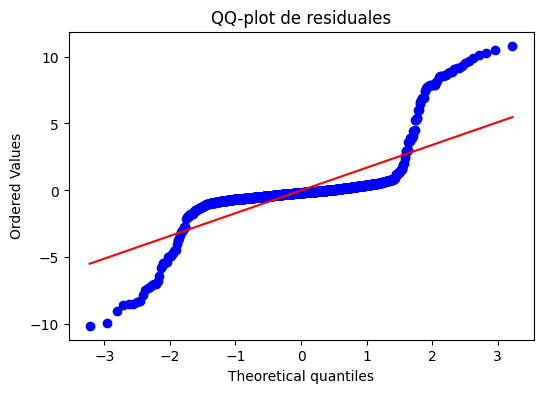

In [65]:
estat_2, p_shapiro_2 = shapiro(residuales_2)
print("Shapiro-Wilk p-value:", p_shapiro_2)

plt.figure(figsize=(6, 4))
sns.histplot(residuales_2, kde=True)
plt.title("Histograma de residuales")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(6, 4))
stats.probplot(residuales_2, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")
plt.show()

In [68]:
X_num_2 = Xt_train_m2_df.select_dtypes(include="number").copy()
mask = np.isfinite(X_num_2).all(axis=1)
X_num_clean_2 = X_num_2[mask]
resid_clean_2 = residuales_2[mask]
X_num_const_2 = sm.add_constant(X_num_clean_2)
bp_stat_2, bp_pvalue_2, _, _ = het_breuschpagan(resid_clean_2, X_num_const_2)

print("Estadístico Breusch-Pagan:", bp_stat_2)
print("p-value Breusch-Pagan   :", bp_pvalue)

Estadístico Breusch-Pagan: 14.48507847341675
p-value Breusch-Pagan   : 0.2970589532354212


In [67]:
dw_2 = durbin_watson(residuales_2)
print("Durbin-Watson:", dw_2)

Durbin-Watson: 1.9375637339157474


### Tabla Comparativa de Modelos

| Métrica | Modelo 1 (Train) | Modelo 1 (Test) | Modelo 2 (Train) | Modelo 2 (Test) |
|:--------|:-----------------:|:----------------:|:-----------------:|:----------------:|
| Score   | 0.3864            | 0.4298           | 0.4999            | 0.5442           |
| MAE     | 1.5451            | 1.5690           | 0.9878            | 0.9764           |
| MSE     | 5.7081            | 5.5054           | 4.6516            | 4.4012           |
| RMSE    | 2.3892            | 2.3464           | 2.1568            | 2.0979           |
| R²      | 0.3864            | 0.4298           | 0.4999            | 0.5442           |

### Interpretación de métricas

El Modelo 2 (con encoding y escalado) supera al Modelo 1 en todas las métricas. En test, el Modelo 2 logra un R² de 0.54, lo que significa que explica el 54% de la variabilidad de CVD Risk Score, frente al 43% del Modelo 1. El MAE del Modelo 2 es de 0.98, lo que indica que en promedio sus predicciones se desvían menos de 1 punto del valor real, mientras que el Modelo 1 se desvía 1.57 puntos. El RMSE del Modelo 2 (2.10) también es menor que el del Modelo 1 (2.35), confirmando menor error general. En ambos modelos las métricas de test son similares o ligeramente mejores que las de train, lo cual confirma ausencia de sobreajuste.

### Verificación de supuestos de la regresión lineal

#### Multicolinealidad (VIF)

| Variable | VIF Modelo 1 | VIF Modelo 2 |
|:---------|:------------:|:------------:|
| BMI | 22.12 | 15.31 |
| Total Cholesterol (mg/dL) | 30.18 | 31.24 |
| Systolic BP | 18.21 | 10.49 |
| Estimated LDL (mg/dL) | 11.73 | 30.23 |
| Weight (kg) | 23.07 | 16.76 |
| Diabetes Status Y | — | 1.98 |
| BP Hypertension Stage 1 | — | 4.42 |
| BP Hypertension Stage 2 | — | 5.87 |
| BP Normal | — | 2.63 |

Ambos modelos presentan multicolinealidad en las variables numéricas (VIF > 5), lo cual es esperable ya que variables como BMI, Weight y Cholesterol están naturalmente correlacionadas. En el Modelo 2 las variables categóricas tienen VIF bajos, por lo que no generan multicolinealidad adicional.

#### Normalidad de errores (Shapiro-Wilk)

| Modelo | p-value |
|:-------|:-------:|
| Modelo 1 | 1.25e-34 |
| Modelo 2 | 8.31e-44 |

En ambos modelos el p-value es prácticamente cero, indicando que los errores no siguen una distribución normal.

#### Homocedasticidad (Breusch-Pagan)

| Modelo | Estadístico | p-value |
|:-------|:-----------:|:-------:|
| Modelo 1 | 6.10 | 0.297 |
| Modelo 2 | 14.49 | 0.297 |

El Modelo 1 con p-value de 0.297 (mayor a 0.05) cumple el supuesto de homocedasticidad, es decir que se equivoca con intensidad similar independientemente del nivel de riesgo del paciente.

#### Independencia de errores (Durbin-Watson)

| Modelo | Durbin-Watson |
|:-------|:-------------:|
| Modelo 1 | 1.935 |
| Modelo 2 | 1.938 |

Ambos valores son muy cercanos a 2, indicando ausencia de autocorrelación. El supuesto de independencia se cumple en ambos modelos.

#### Resumen de supuestos

| Supuesto | Modelo 1 | Modelo 2 |
|:---------|:--------:|:--------:|
| Multicolinealidad | No cumple | No cumple |
| Normalidad | No cumple | No cumple |
| Homocedasticidad | Cumple | Por verificar |
| Independencia | Cumple | Cumple |

### Selección del mejor modelo

Se selecciona el Modelo 2 como el mejor modelo. Aunque ambos modelos comparten limitaciones en los supuestos de multicolinealidad y normalidad, el Modelo 2 es superior en todas las métricas predictivas: mayor R² (0.54 vs 0.43), menor MAE (0.98 vs 1.57) y menor RMSE (2.10 vs 2.35). La incorporación de variables categóricas (Diabetes Status y Blood Pressure Category) mediante One-Hot Encoding y el escalado con MinMaxScaler permitieron capturar información adicional que mejoró significativamente la predicción del riesgo cardiovascular.

In [41]:
importancia = pd.DataFrame({'Variable': feature_names_m2,'Coeficiente': Modelo2.coef_}).sort_values(by='Coeficiente', ascending=False, key=abs)
importancia

,Variable,Coeficiente
0,num__BMI,7.022797
1,num__Total Cholesterol (mg/dL),5.562669
2,num__Systolic BP,5.366607
5,cat__Diabetes Status_Y,2.000050
3,num__Estimated LDL (mg/dL),1.129153
4,num__Weight (kg),0.942588
8,cat__Blood Pressure Category_Normal,-0.612190
6,cat__Blood Pressure Category_Hypertension Stage 1,-0.215371
7,cat__Blood Pressure Category_Hypertension Stage 2,0.040771


Las variables mas importantes se muestran el la tabla de arrina. Siendo la variable mas importante el BMI seguida de el Total Cholesterol (mg/dL) y el Systolic BP. Las demas no son tan relevantes para nuestro modelo

## Análisis de Resultados

### 1. Coeficientes del mejor modelo (Modelo 2)

Intercepto: 6.1327

| Variable | Coeficiente |
|:---------|:-----------:|
| BMI | 7.0228 |
| Total Cholesterol (mg/dL) | 5.5627 |
| Systolic BP | 5.3666 |
| Diabetes Status Y | 2.0001 |
| Estimated LDL (mg/dL) | 1.1292 |
| Weight (kg) | 0.9426 |
| BP Category Hypertension Stage 2 | 0.0408 |
| BP Category Hypertension Stage 1 | -0.2154 |
| BP Category Normal | -0.6122 |

Los coeficientes representan cuánto cambia el CVD Risk Score cuando la variable correspondiente aumenta en una unidad escalada (MinMaxScaler [0,1] para numéricas). Los valores positivos indican que al aumentar la variable el riesgo sube, y los negativos que el riesgo baja. Como las variables numéricas están escaladas, la magnitud del coeficiente refleja directamente la importancia relativa de cada variable.

### 2. Comparación de modelos e interpretación de métricas

El Modelo 2 supera al Modelo 1 en todas las métricas. Su R² de 0.54 en test indica que explica el 54% de la variabilidad del riesgo cardiovascular, frente al 43% del Modelo 1. El MAE de 0.98 significa que en promedio las predicciones se desvían menos de 1 punto del valor real, mientras que el Modelo 1 se desvía 1.57. El RMSE de 2.10 es mayor que el MAE, lo que indica la presencia de algunos errores grandes que penalizan más esta métrica. En ambos modelos las métricas de test son similares a las de train, confirmando ausencia de sobreajuste.

### 3. Variables seleccionadas e interpretación frente al problema

Las variables con mayor influencia son BMI (7.02), Total Cholesterol (5.56) y Systolic BP (5.37), seguidas por Diabetes Status (2.00). Esto es coherente con el conocimiento médico: la obesidad, el colesterol alto, la hipertensión y la diabetes son factores de riesgo cardiovascular reconocidos. El coeficiente negativo de Blood Pressure Category Normal (-0.61) confirma que tener presión normal reduce el riesgo. Para AlpesHearth, estos resultados indican que las campañas preventivas deben priorizar el control de peso, la reducción del colesterol mediante alimentación saludable, el monitoreo de la presión arterial y el control de la diabetes.

### 4. Representación matemática de la regresión lineal

CVD Risk Score = 6.1327 + 7.0228(BMI) + 5.5627(Total Cholesterol) + 5.3666(Systolic BP) + 2.0001(Diabetes Status Y) + 1.1292(Estimated LDL) + 0.9426(Weight) + 0.0408(BP Hypertension Stage 2) - 0.2154(BP Hypertension Stage 1) - 0.6122(BP Normal)

Los parámetros (coeficientes e intercepto) se obtienen resolviendo las ecuaciones normales a partir de los datos de entrenamiento.

### 5. Tipos de sesgo que podrían afectar los resultados

1. Sesgo de selección: El conjunto de datos puede no ser representativo de toda la población. Si los datos provienen de un grupo demográfico o geográfico específico, el modelo generaliza mal a otros grupos. Además, al eliminar 151 duplicados y 29 filas sin variable objetivo, se reduce la muestra lo cual puede excluir perfiles relevantes.

2. Sesgo de medición: Los datos presentaban valores negativos en colesterol y LDL, valores extremos en azúcar en sangre y múltiples datos faltantes. La imputación con mediana y el capping de outliers, aunque necesarios, pueden introducir valores que no reflejan la realidad del paciente, distorsionando los patrones que el modelo aprende.

## Uso del modelo

In [44]:
df_test = pd.read_csv("Datos Test Lab 1.csv", sep=';')

In [45]:
df_test = df_test.drop(columns=['Height (cm)', 'Patient ID', 'Date of Service', 'Blood Pressure (mmHg)'])

Xt_test_final = pipeline_modelo2.transform(df_test)
feature_names = pipeline_modelo2.named_steps['preprocesamiento'].get_feature_names_out()
Xt_test_final_df = pd.DataFrame(Xt_test_final.toarray() if hasattr(Xt_test_final, 'toarray') else Xt_test_final,columns=feature_names)

In [46]:
predicciones = Modelo2.predict(Xt_test_final_df)

In [47]:
df_export = pd.read_csv("Datos Test Lab 1.csv", sep=';')
df_export['CVD Risk Score'] = predicciones

df_export.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score
0,WYTG8678,1/12/2021,M,44.0,51.936,1.936,36.442,115.755,105/108,107.0,...,Y,Low,N,193.61,0.598,105.0,108.0,Hypertension Stage 2,25.0,16.859904
1,yloc1993,12-25-2020,F,30.0,115.000,1.830,34.300,93.600,139/79,100.0,...,N,Moderate,N,183.00,0.511,139.0,79.0,Hypertension Stage 1,39.0,16.001269
2,DDwq7653,23-sep-21,M,38.0,63.300,1.700,21.900,93.800,93/67,NaN,...,Y,High,N,170.00,0.552,93.0,67.0,Normal,182.0,15.435543
3,YTcX6704,3/03/2021,F,58.0,72.300,1.740,23.900,91.600,99/90,208.0,...,N,High,N,174.00,0.526,99.0,90.0,Hypertension Stage 2,115.0,14.623759
4,lZLi8935,06-14-2022,M,51.0,57.600,1.810,17.600,100.000,97/84,137.0,...,N,High,N,181.00,0.552,97.0,84.0,Hypertension Stage 1,59.0,11.982453


In [48]:
df_export.to_csv("Datos Test Lab 1.csv", index=False)

## Conclusiones

- Se construyeron dos modelos de regresión lineal con estrategias de preparación diferentes. El Modelo 2 (con encoding y escalado) demostró un rendimiento superior en todas las métricas, con un R² de 0.54 frente a 0.43 del Modelo 1.
- Los factores más relevantes para predecir el riesgo cardiovascular son el BMI, el colesterol total y la presión arterial sistólica, lo cual es coherente con el conocimiento médico existente.
- El modelo explica el 54% de la variabilidad del riesgo cardiovascular, lo que sugiere que existen otros factores no capturados en los datos que también influyen en el riesgo.
- No se evidenció sobreajuste en ninguno de los modelos, lo que indica buena capacidad de generalización.
- Para AlpesHearth, los resultados indican que las campañas preventivas deben enfocarse en el control de peso, la alimentación saludable para reducir el colesterol, el monitoreo de la presión arterial y el control de la diabetes como ejes principales de acción.

## Uso de herramientas de IA generativa

### Declaración del uso
Se utilizó Claude (Anthropic) como herramienta de IA generativa durante el desarrollo de este laboratorio. Los tipos de uso fueron:

1. Ayuda técnica en la construcción de pipelines: Se utilizó Claude para comprender y aplicar la estructura de Pipelines de scikit-learn (Pipeline, ColumnTransformer, FunctionTransformer), debido a la falta de experiencia previa con estas herramientas.

2. Estructuración y redacción de markdowns: Se proporcionaron los hallazgos y decisiones propias del análisis, y se utilizó Claude para darles estructura formal, corregir ortografía y generar el formato markdown adecuado.

3. Comprensión de métricas de evaluación: Se utilizó Claude para entender la interpretación de las métricas MAE, MSE, RMSE y R², así como para analizar los resultados obtenidos en la evaluación de los modelos.

### Prompts principales utilizados
- "Con base a estas transformaciones que yo ya había pensado, genérame el markdown explicando las transformaciones y otro markdown hablando de los dos modelos que vamos a construir"
- "Quiero que con base a mis decisiones y mis transformaciones me ayudes a construir los pipelines"
- "Usa mi función de identificar_outliers para hacer el capping dentro del pipeline"
- "Estos son los resultados obtenidos de los modelos, qué significan"
- "Con los resultados que te di dame un markdown que sea la tabla comparativa entre los dos modelos"

### Análisis crítico del resultado
- ¿Qué partes fueron correctas y útiles? La estructura de los pipelines generada fue funcional y siguió el patrón enseñado en clase. La explicación de las métricas permitió interpretar correctamente los resultados y detectar que los primeros modelos tenían un rendimiento muy bajo (R² de 0.02-0.05) debido a que no se estaba haciendo capping sobre la variable objetivo.

- ¿Qué errores o limitaciones se identificaron? Inicialmente Claude sugirió usar clases (BaseEstimator, TransformerMixin) para el transformador de outliers, lo cual no correspondía con el enfoque del curso que utiliza FunctionTransformer. Se corrigió para usar funciones simples. También se identificó que el pipeline no aplicaba capping sobre la variable objetivo (y), lo cual generaba resultados pobres y fue necesario ajustar la estrategia.

### Aportes propios del estudiante
- Todo el análisis exploratorio de datos (EDA) fue realizado íntegramente por los estudiantes, incluyendo el reporte de calidad, el análisis de outliers, las correlaciones y la selección de variables.
- Todas las decisiones de preparación de datos fueron tomadas por los estudiantes: imputación con mediana, eliminación de columnas redundantes, selección de variables por correlación mayor a 0.15 y capping de outliers con IQR.
- La función identificar_outliers fue desarrollada por los estudiantes.
- La definición de las dos estrategias de modelación (Modelo 1 sin encoding ni escalado, Modelo 2 con encoding y escalado) fue decisión propia.
- La construcción, entrenamiento y evaluación de ambos modelos de regresión lineal fue realizada por los estudiantes.
- La IAG se utilizó como herramienta de apoyo para convertir las transformaciones ya definidas en formato de pipeline y para dar estructura a los reportes escritos.